# Lichess Matchmaking Fairness Analysis — Report

*A platform-analytics report on matchmaking quality and player experience. This is a clean, narrative version of the working notebook `Lichess Matchmaking Fairness Analysis.ipynb`; all analysis, numbers, and findings are identical.*


This project is best understood as a **platform analytics exercise about matchmaking quality and player experience**, not as a generic chess EDA. 

From the perspective of a data analyst at Lichess, the questions that matter are product questions: does the rating system produce fair matchups, 

does a rating gap reliably predict who wins, and where does matchmaking break down? 

The core spine question is whether rating difference is a dependable predictor of game outcome — and where that relationship weakens or fails. 

Everything below reads the data through that lens: matchmaking quality is the outcome of interest, and game-level features (how games end, how long they run, 

which openings get played) are treated as signals about the player experience those matchups create.



## 1. Data Prep (brief)


**Q: What does the dataset contain?**


In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")


In [2]:
df = pd.read_csv("../data/chess.csv")


In [3]:
df.describe()
df.shape


(20058, 16)

**Q: Is any data missing?**


In [4]:
df.isnull().sum()


id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

**Q: When were the games played, and are the timestamps reliable?**


In [5]:
df['created_at'] = pd.to_datetime(df['created_at'], unit='ms')
df['last_move_at'] = pd.to_datetime(df['last_move_at'], unit='ms')


df[["created_at", "last_move_at"]]


,created_at,last_move_at
0,2017-08-31 20:06:40.000,2017-08-31 20:06:40.000
1,2017-08-30 21:53:20.000,2017-08-30 21:53:20.000
2,2017-08-30 21:53:20.000,2017-08-30 21:53:20.000
3,2017-08-30 16:20:00.000,2017-08-30 16:20:00.000
4,2017-08-29 18:06:40.000,2017-08-29 18:06:40.000
...,...,...
20053,2017-07-11 16:35:14.342,2017-07-11 16:40:36.076
20054,2017-07-10 14:48:09.760,2017-07-10 15:00:33.979
20055,2017-07-10 14:44:37.493,2017-07-10 14:47:30.327
20056,2017-07-10 14:15:27.019,2017-07-10 14:31:13.718


In [6]:

sametimes_len = (df[df['created_at'] == df['last_move_at']].shape[0])

total_len = df.shape[0]

print(f"Percentage of games where created_at == last_move_at: {sametimes_len/total_len*100:.2f}%")



Percentage of games where created_at == last_move_at: 42.62%


Roughly 43% of rows have identical `created_at` and `last_move_at` values even though many of those games run dozens of turns, so the timestamps are treated as a low-precision collection artifact — game duration is never inferred from them.


**Q: How are openings and their variations structured in the data?**


In [7]:
x = df["opening_name"].str.split(":", expand = True, n=1)
df["opening_name"] = x[0]
df["variation"] = x[1]

df["variation"] = df["variation"].str.strip()
df["opening_name"] = df["opening_name"].str.strip()


Each `opening_name` is split on its first colon into the base opening (e.g. "Ruy Lopez") and the named variation (e.g. "Berlin Defense: Mortimer Trap"); rows without a colon simply have no named variation.


## 2. Core Finding: Rating Gap vs Outcome


**Q: How close are typical matchups by rating?**


In [8]:
df["rating_diff"] = df["white_rating"] - df["black_rating"]
df["rating_diff_abs"] = df["rating_diff"].abs()
df["rating_diff"].describe()


count    20058.000000
mean         7.799880
std        249.036667
min      -1605.000000
25%       -108.000000
50%          3.000000
75%        122.000000
max       1499.000000
Name: rating_diff, dtype: float64

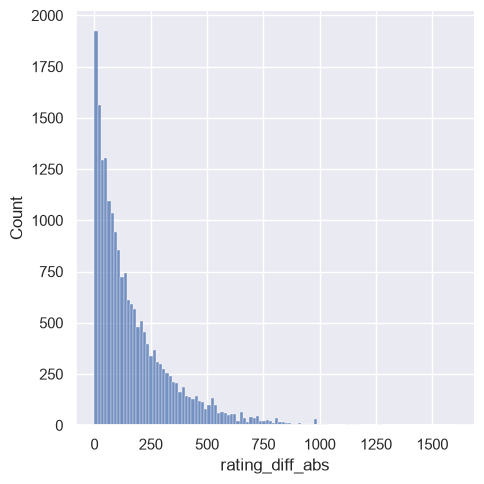

In [9]:
sns.displot(df["rating_diff_abs"])


The signed gap is symmetric around zero (mean +7.8), but the absolute gap is right-skewed: most games are fairly close, with a long tail of large mismatches.


**Q: Who wins overall?**


In [10]:
df['winner'].value_counts(normalize=True)


winner
white    0.498604
black    0.454033
draw     0.047363
Name: proportion, dtype: float64

White wins roughly half of games and draws are rare (~4.7%), so results are almost always decisive.


**Q: Does the higher-rated player win more often as the rating gap grows?**


In [11]:
rating_diff_bins = pd.qcut(df["rating_diff_abs"], q=5)

rating_diff_bins


0        (284.0, 1605.0]
1           (34.0, 83.0]
2         (-0.001, 34.0]
3         (-0.001, 34.0]
4           (34.0, 83.0]
              ...       
20053    (284.0, 1605.0]
20054       (34.0, 83.0]
20055       (34.0, 83.0]
20056      (83.0, 156.0]
20057      (83.0, 156.0]
Name: rating_diff_abs, Length: 20058, dtype: category
Categories (5, interval[float64, right]): [(-0.001, 34.0] < (34.0, 83.0] < (83.0, 156.0] < (156.0, 284.0] < (284.0, 1605.0]]

In [12]:
df["higher_rated_player"] = np.where(df["white_rating"] > df["black_rating"], "white", "black")
df["higher_rated_won"] = np.where(df["higher_rated_player"] == df["winner"], True, False)


In [13]:
win_rate_by_rating_gap = df.groupby(rating_diff_bins)["higher_rated_won"].agg(["mean", "count"])


win_rate_by_rating_gap 


,mean,count
rating_diff_abs,,
"(-0.001, 34.0]",0.487401,4048
"(34.0, 83.0]",0.524472,4025
"(83.0, 156.0]",0.602864,3981
"(156.0, 284.0]",0.686279,3994
"(284.0, 1605.0]",0.803491,4010


Favorite win rate climbs monotonically from **48.7%** (gaps ≤34 points) to **80.3%** (gaps ≥284 points). Close games are near coin-flips; big gaps are near-certainties.


**Q: How many games fall into each bucket, and what share of all games is that?**


In [14]:
findings_summary = win_rate_by_rating_gap.copy()
findings_summary["share_of_games"] = findings_summary["count"] / len(df) * 100
findings_summary = findings_summary.rename(columns={"mean": "favorite_win_rate", "count": "games"})
findings_summary



,favorite_win_rate,games,share_of_games
rating_diff_abs,,,
"(-0.001, 34.0]",0.487401,4048,20.181474
"(34.0, 83.0]",0.524472,4025,20.066806
"(83.0, 156.0]",0.602864,3981,19.847442
"(156.0, 284.0]",0.686279,3994,19.912254
"(284.0, 1605.0]",0.803491,4010,19.992023


**Q: Headline chart — favorite win rate by rating-gap bucket.**


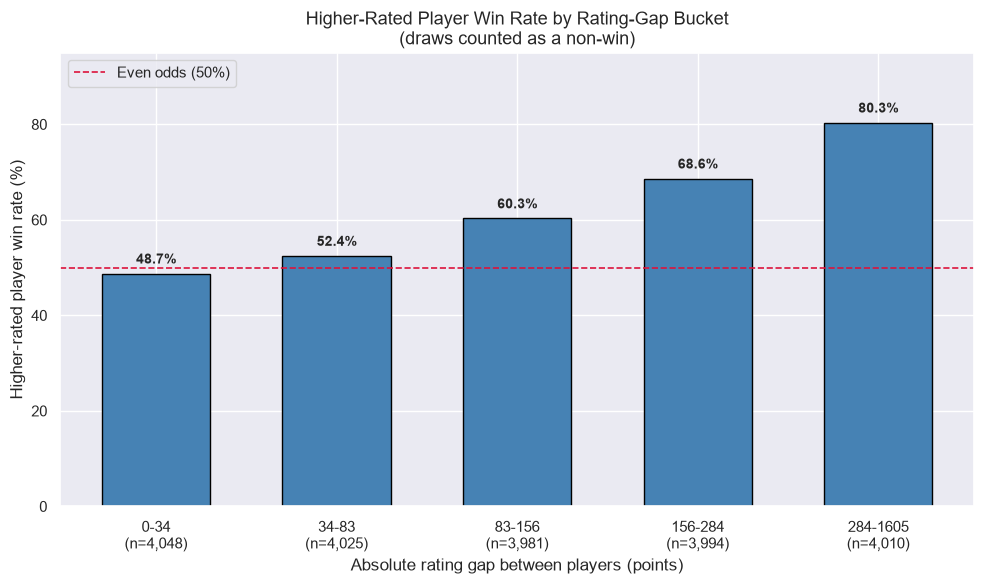

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

rates = win_rate_by_rating_gap["mean"] * 100
counts = win_rate_by_rating_gap["count"]


def bucket_label(interval):
    lo = max(0, interval.left)
    return f"{lo:.0f}-{interval.right:.0f}"


labels = [f"{bucket_label(it)}\n(n={c:,})" for it, c in zip(win_rate_by_rating_gap.index, counts)]

ax.bar(labels, rates, color="steelblue", edgecolor="black", width=0.6)
for i, r in enumerate(rates):
    ax.text(i, r + 1.5, f"{r:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(50, color="crimson", linestyle="--", linewidth=1.2, label="Even odds (50%)")
ax.set_ylim(0, 95)
ax.set_xlabel("Absolute rating gap between players (points)")
ax.set_ylabel("Higher-rated player win rate (%)")
ax.set_title("Higher-Rated Player Win Rate by Rating-Gap Bucket\n(draws counted as a non-win)", fontsize=13)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()



**Q: How large is the "effectively pre-decided" tail?**


In [16]:
(df['rating_diff_abs'] > 300).mean()


np.float64(0.18202213580616214)

18.2% of games are played with a rating gap above 300 points — roughly 1 in 5 — and the favorite wins about 80% of those.


## 3. Supporting Analysis: Victory Status & Opening Theory


**Q: Do mismatched games end differently than close ones?**


In [17]:
pd.crosstab(index= rating_diff_bins, columns=df["victory_status"], normalize="index" )*100


victory_status,draw,mate,outoftime,resign
rating_diff_abs,,,,
"(-0.001, 34.0]",4.841897,30.410079,8.522727,56.225296
"(34.0, 83.0]",5.440994,29.565217,9.515528,55.478261
"(83.0, 156.0]",4.621954,30.419493,8.515448,56.443105
"(156.0, 284.0]",4.406610,32.173260,8.012018,55.408112
"(284.0, 1605.0]",3.266833,35.112219,7.306733,54.314214


The victory mix is nearly flat across gap buckets: checkmate endings rise modestly from 30.4% to 35.1%, out-of-time endings dip from 8.5% to 7.3%, and resignation stays dominant (~55-56%) everywhere. Mismatch changes *who wins*, not *how games end*.


**Q: Does opening theory depth relate to game length?**


In [18]:
df["opening_ply"].corr(df["turns"])


np.float64(0.05599876874489277)

The correlation is very weak (**0.056**) — how deep the game goes into book tells you almost nothing about how long it will run.


**Q: Does deeper opening theory change how games end?**


In [19]:
df['opening_ply_bucket'] = pd.qcut(df['opening_ply'], q=5)
pd.crosstab(index = df["opening_ply_bucket"], columns=df["victory_status"], normalize="index")


victory_status,draw,mate,outoftime,resign
opening_ply_bucket,,,,
"(0.999, 2.0]",0.044891,0.345982,0.093254,0.515873
"(2.0, 4.0]",0.042218,0.340541,0.085172,0.532068
"(4.0, 5.0]",0.046154,0.304762,0.084982,0.564103
"(5.0, 7.0]",0.042806,0.298454,0.074019,0.584721
"(7.0, 28.0]",0.053606,0.248564,0.077856,0.619974


Games that go deeper into book end more often in resignation (51.6% → 62.0%) and less often in checkmate (34.6% → 24.9%) — a modest shift in how decisive games conclude.


## 4. Supporting Analysis: Rated vs Unrated


**Q: How common are rated vs unrated games?**


<Axes: xlabel='rated', ylabel='count'>

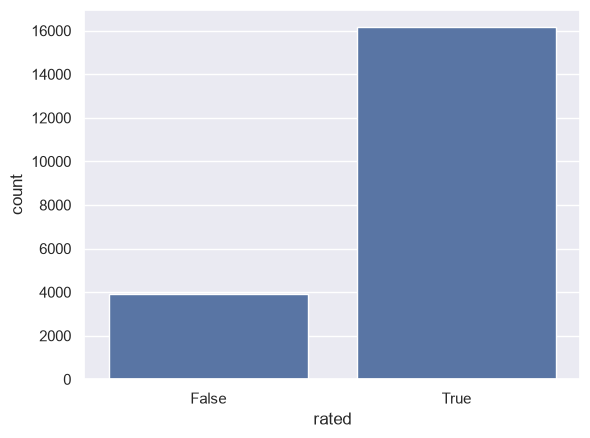

In [20]:
sns.countplot(x="rated", data=df)


**Q: Is the rating-gap → outcome relationship steeper in rated games?**


In [21]:
rated_win_rate_comparison = df.groupby([rating_diff_bins, "rated"])["higher_rated_won"].agg(["mean", "count"])
rated_win_rate_comparison


mean  count
rating_diff_abs rated                 
(-0.001, 34.0]  False  0.485714    525
                True   0.487653   3523
(34.0, 83.0]    False  0.508946    503
                True   0.526689   3522
(83.0, 156.0]   False  0.581498    681
                True   0.607273   3300
(156.0, 284.0]  False  0.639019    856
                True   0.699171   3138
(284.0, 1605.0] False  0.735426   1338
                True   0.837575   2672

The same upward trend appears in both, but it is steeper in rated games: in the widest gap bucket the favorite wins **83.8% of rated games vs 73.5% of unrated games**.


**Q: Do rated and unrated games end differently?**


In [22]:
counts = df.groupby(["rated", "victory_status"]).size().unstack(fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

percentages



victory_status,draw,mate,outoftime,resign
rated,,,,
False,5.764796,30.207533,8.224443,55.803228
True,4.215413,31.853915,8.412256,55.518415


<Axes: ylabel='rated'>

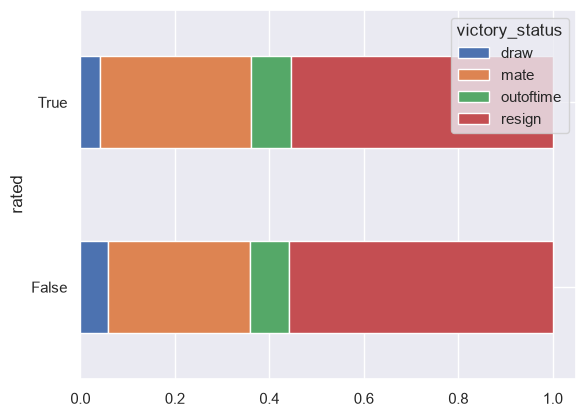

In [23]:
# Relationship Between Rated Vs Unrated in How Games End
sns.set_theme(style="darkgrid")

pd.crosstab(index=df["rated"], columns=df["victory_status"], normalize="index").plot(kind="barh", stacked=True)



Victory mixes are nearly identical — roughly 55% resignations and 31% checkmates in both rated and unrated games.


**Q: Are unrated games shorter?**


In [24]:
turns_v_rated = df.groupby(["rated"])["turns"].describe()
turns_v_rated


,count,mean,std,min,25%,50%,75%,max
rated,,,,,,,,
False,3903.0,54.271586,32.162533,1.0,31.0,50.0,72.0,206.0
True,16155.0,61.962550,33.732775,1.0,39.0,57.0,80.0,349.0


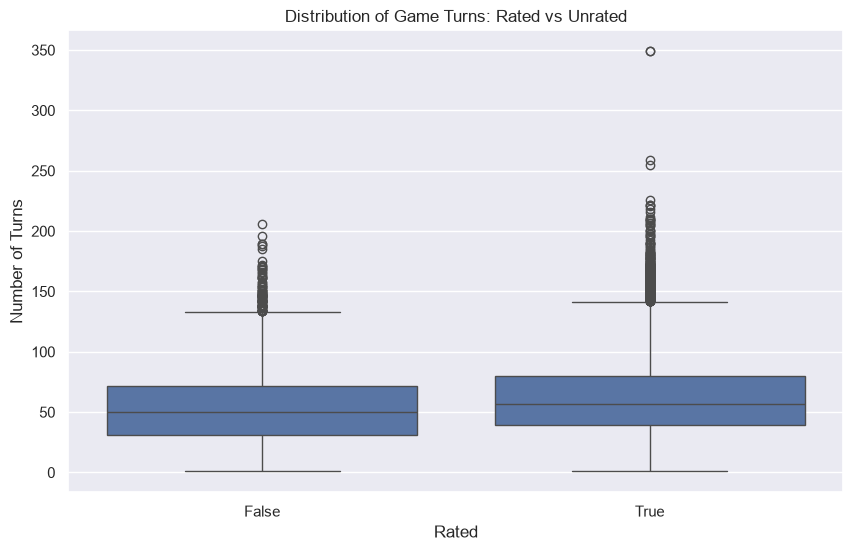

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="rated", y="turns")
plt.xlabel("Rated")
plt.ylabel("Number of Turns")
plt.title("Distribution of Game Turns: Rated vs Unrated")
plt.show()


Unrated games average **54.3 turns** vs **62.0 turns** for rated games (medians 50 vs 57) — unrated play looks like a lower-commitment environment.


## 5. Opening/Variation Matchup Table


**Q: Which base openings are most common in this dataset?**


In [26]:
df["opening_name"].value_counts()


opening_name
Sicilian Defense                                                   2573
French Defense                                                     1306
Queen's Pawn Game                                                  1059
Italian Game                                                        981
King's Pawn Game                                                    917
                                                                   ... 
King's Gambit Accepted |  Rosentreter-Testa Gambit                    1
King's Gambit Accepted |  Kieseritzky Gambit |  Kolisch Defense       1
King's Gambit Accepted |  Salvio Gambit                               1
King's Gambit Accepted |  Ghulam-Kassim Gambit                        1
King's Gambit |  Falkbeer Countergambit |  Miles Gambit               1
Name: count, Length: 227, dtype: int64

**Q: Which variations carry the highest and lowest white win rates?**


In [27]:
opening_winrate = df.groupby(["opening_name","variation", "winner"]).size().unstack(fill_value = 0)

opening_winrate["Games"] = opening_winrate.sum(axis=1)
opening_winrate = opening_winrate[opening_winrate["Games"] >= 20]

opening_winrate["white_winrate"] = (opening_winrate["white"]/opening_winrate["Games"]) * 100
opening_winrate["black_winrate"] =(opening_winrate["black"]/opening_winrate["Games"]) * 100
opening_winrate["draw_rate"] =(opening_winrate["draw"]/opening_winrate["Games"]) * 100

opening_winrate = opening_winrate[opening_winrate["Games"] >= 30]
opening_winrate.sort_values(by = ["white_winrate","Games"], ascending=False)


,winner,black,draw,white,Games,white_winrate,black_winrate,draw_rate
opening_name,variation,,,,,,,
Russian Game,Damiano Variation,8,0,32,40,80.000000,20.000000,0.000000
Zukertort Opening,Queen's Gambit Invitation,13,3,37,53,69.811321,24.528302,5.660377
French Defense,Advance Variation #3,13,0,29,42,69.047619,30.952381,0.000000
English Opening,Agincourt Defense,8,2,21,31,67.741935,25.806452,6.451613
Ruy Lopez,Morphy Defense | Caro Variation,11,2,27,40,67.500000,27.500000,5.000000
...,...,...,...,...,...,...,...,...
French Defense,Advance Variation | Nimzowitsch System,23,2,13,38,34.210526,60.526316,5.263158
Italian Game,Schilling-Kostic Gambit,25,3,13,41,31.707317,60.975610,7.317073
French Defense,King's Indian Attack,22,0,10,32,31.250000,68.750000,0.000000


With the ≥30-game filter, white win rates range from **80.0%** (Russian Game: Damiano Variation, n=40) down to **30.0%** (Sicilian Defense: Modern Variations Main Line, n=30). Small samples near the threshold mean these are directional leads, not confirmed effects.


## 6. Findings


**1. Rating gap is a strong, monotonic predictor of outcome — but close games are genuinely competitive.** 

Higher-rated players win just 48.7% of games when the gap is within 34 points, rising steadily to 80.3% when the gap exceeds 284 points 

(quintile buckets, roughly 4,000 games each; summary table and chart above). 

*So what:* the matchmaker behaves the way an Elo system should — outcomes become more lopsided as mismatch grows — while tight matches stay near coin-flips, 

which is a healthy sign for competitive play. The real design risk sits in the tail, not in the middle bands.

**2. A real mismatch tail exists: roughly 1 in 5 games is effectively pre-decided.** 

18.2% of all games are played with a rating gap above 300 points, and in the widest quintile (284+ points) the higher-rated player wins 80.3% of the time. 

*So what:* the platform should monitor whether that tail is driven by matchmaking-queue necessity (off-peak hours, thin rating bands, 

new-account rating variance) rather than being an intentional feature of the ladder.

**3. Mismatch changes who wins, not how games end.** 

The victory_status mix is almost flat across rating-gap buckets: checkmate endings rise modestly from 30.4% to 35.1%, 

out-of-time endings dip from 8.5% to 7.3%, and resignation stays the dominant outcome (~55-56%) in every bucket. 

*So what:* imbalanced matchups do not produce visibly "broken" or abandoned games — their cost shows up as predictable, frustrating losses 

rather than anomalous game flow, which is a retention risk that outcome balance alone won't surface.

**4. Rated games are more predictable and slightly longer.** 

The higher-rated player wins 83.8% of rated games versus 73.5% of unrated games in the widest gap bucket, 

and rated games average 62.0 turns versus 54.3 for unrated (medians 57 vs 50). 

*So what:* unrated play is a lower-commitment, noisier environment; keeping both populations in the analysis is defensible, 

but matchmaking-quality monitoring should weight rated games more heavily.

**5. Openings: book depth is barely tied to game length, but variation win rates show large — and as-yet unvalidated — spreads.** 

The correlation between opening_ply and turns is very weak (0.056), yet games that go deeper into book end more often in resignation (51.6% → 62.0%) 

and less often in mate (34.6% → 24.9%). In the opening/variation table, white win rates range from 80.0% 

(Russian Game: Damiano Variation, 40 games) down to 30.0% (Sicilian Defense: Modern Variations Main Line, 30 games). 

*So what:* the variation win-rate spread is the most product-relevant lead here — it is the natural basis for a 

"which lines work against this opening" feature — but the small samples make these candidates for validation rather than confirmed effects.



## 7. Limitations


Four caveats apply to this write-up. First, `created_at` and `last_move_at` are identical for ~43% of rows even though many of those games run 

dozens of turns, which points to a low-precision timestamp collection artifact rather than instant games; the analysis therefore never treats 

timestamp deltas as a measure of game duration. Second, the `higher_rated_won` metric counts a draw as "the favorite did not win," 

a deliberate simplification that keeps the interpretation clean but slightly understates how often the favorite avoids losing. 

Third, the opening/variation win-rate table is filtered to variations with at least 30 games, and many entries sit right at that threshold; 

results near the cutoff should be read as directional candidates for further investigation, and only rows with 100+ games should be treated as reliable. 

Finally, this dataset contains no session, churn, or retention data, so any claims about player experience are inferred from proxies 

(game length, resignation behavior, outcome predictability) rather than directly measured.

